In [1]:
import pandas as pd

In [2]:
caltech = pd.read_json(
    "acndata_download/acndata_caltech_sessions.jsonl",
    lines=True
)

jpl = pd.read_json(
    "acndata_download/acndata_jpl_sessions.jsonl",
    lines=True
)

caltech["site"] = "caltech"
jpl["site"] = "jpl"

df = pd.concat([caltech, jpl], ignore_index=True)

df.head()

,_id,userInputs,userID,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,site
0,61550519f9af8b76960e169e,"[{'userID': 19055, 'milesRequested': 100, 'WhP...",19055.0,2_39_81_4550_2021-09-14 01:52:31.129163,2-39-81-4550,11900388,2,39,"Tue, 14 Sep 2021 01:52:37 GMT","Tue, 14 Sep 2021 03:05:10 GMT",45.064,NaN,America/Los_Angeles,caltech
1,61550519f9af8b76960e169d,"[{'userID': 1082, 'milesRequested': 20, 'WhPer...",1082.0,2_39_91_437_2021-09-13 23:10:59.528292,2-39-91-437,CA-317,2,39,"Mon, 13 Sep 2021 23:11:12 GMT","Tue, 14 Sep 2021 01:43:11 GMT",2.018,"Tue, 14 Sep 2021 00:13:35 GMT",America/Los_Angeles,caltech
2,61550519f9af8b76960e169c,"[{'userID': 3905, 'milesRequested': 100, 'WhPe...",3905.0,2_39_81_4550_2021-09-13 22:33:04.543952,2-39-81-4550,11900388,2,39,"Mon, 13 Sep 2021 22:33:07 GMT","Mon, 13 Sep 2021 23:06:55 GMT",17.720,NaN,America/Los_Angeles,caltech
3,61550519f9af8b76960e169b,"[{'userID': 6481, 'milesRequested': 25, 'WhPer...",6481.0,2_39_123_23_2021-09-13 21:16:44.026068,2-39-123-23,CA-313,2,39,"Mon, 13 Sep 2021 21:17:04 GMT","Tue, 14 Sep 2021 01:01:49 GMT",6.715,"Mon, 13 Sep 2021 23:18:07 GMT",America/Los_Angeles,caltech
4,61550519f9af8b76960e169a,"[{'userID': 431, 'milesRequested': 100, 'WhPer...",431.0,2_39_89_25_2021-09-13 21:12:53.318460,2-39-89-25,CA-315,2,39,"Mon, 13 Sep 2021 21:12:53 GMT","Tue, 14 Sep 2021 00:25:36 GMT",2.285,"Mon, 13 Sep 2021 21:41:31 GMT",America/Los_Angeles,caltech


**Check Missing and Duplicated Session Values**

In [3]:
df.info()

display(df.isnull().sum().sort_values(ascending=False))

df.duplicated(subset=["site", "sessionID"]).sum()

<class 'pandas.DataFrame'>
RangeIndex: 65062 entries, 0 to 65061
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               65062 non-null  str    
 1   userInputs        47847 non-null  object 
 2   userID            47847 non-null  float64
 3   sessionID         65062 non-null  str    
 4   stationID         65062 non-null  str    
 5   spaceID           65062 non-null  str    
 6   siteID            65062 non-null  int64  
 7   clusterID         65062 non-null  int64  
 8   connectionTime    65062 non-null  str    
 9   disconnectTime    65062 non-null  str    
 10  kWhDelivered      65062 non-null  float64
 11  doneChargingTime  60970 non-null  str    
 12  timezone          65062 non-null  str    
 13  site              65062 non-null  str    
dtypes: float64(2), int64(2), object(1), str(9)
memory usage: 6.9+ MB


userInputs          17215
userID              17215
doneChargingTime     4092
_id                     0
stationID               0
sessionID               0
spaceID                 0
siteID                  0
connectionTime          0
clusterID               0
disconnectTime          0
kWhDelivered            0
timezone                0
site                    0
dtype: int64

np.int64(0)

**Data is being cleaned, to make sure all data are true values**

In [4]:
# List the columns that contain date and time values.
date_columns = [
    "connectionTime",
    "disconnectTime",
    "doneChargingTime"
]

# Convert each date column into a proper datetime format.
for column in date_columns:
    df[column] = pd.to_datetime(
        df[column],
        errors="coerce", 
        utc=True          
    )

# Convert the delivered energy column into numeric values.
df["kWhDelivered"] = pd.to_numeric(
    df["kWhDelivered"],
    errors="coerce"  
)

# Remove sessions missing the essential values needed for the study.
df = df.dropna(
    subset=[
        "sessionID",
        "connectionTime",
        "kWhDelivered"
    ]
)

# Remove duplicate sessions within each site.
df = df.drop_duplicates(
    subset=["site", "sessionID"],
    keep="first"  # Keep the first copy of each duplicated session.
)

# Remove impossible negative energy values.
df = df[df["kWhDelivered"] >= 0]

# Keep sessions with no disconnection time or with a valid time order.
df = df[
    df["disconnectTime"].isna()
    | (df["disconnectTime"] >= df["connectionTime"])
]

# Convert connection time from UTC to the local California timezone.
df["connectionTimeLocal"] = (
    df["connectionTime"]
    .dt.tz_convert("America/Los_Angeles")
)

# Extract only the local connection date for daily aggregation later.
df["date"] = (
    df["connectionTimeLocal"]
    .dt.date
)

# Reset the row numbers after removing invalid and duplicate records.
df = df.reset_index(drop=True)

In [5]:
cleaning_summary = pd.Series({
    "rows_after_cleaning": len(df),
    "missing_required_values": df[
        ["sessionID", "connectionTime", "kWhDelivered"]
    ].isnull().sum().sum(),
    "duplicate_sessions": df.duplicated(
        subset=["site", "sessionID"]
    ).sum(),
    "negative_energy_values": (
        df["kWhDelivered"] < 0
    ).sum()
})

display(cleaning_summary)

df.head()

rows_after_cleaning        65062
missing_required_values        0
duplicate_sessions             0
negative_energy_values         0
dtype: int64

,_id,userInputs,userID,sessionID,stationID,spaceID,siteID,clusterID,connectionTime,disconnectTime,kWhDelivered,doneChargingTime,timezone,site,connectionTimeLocal,date
0,61550519f9af8b76960e169e,"[{'userID': 19055, 'milesRequested': 100, 'WhP...",19055.0,2_39_81_4550_2021-09-14 01:52:31.129163,2-39-81-4550,11900388,2,39,2021-09-14 01:52:37+00:00,2021-09-14 03:05:10+00:00,45.064,NaT,America/Los_Angeles,caltech,2021-09-13 18:52:37-07:00,2021-09-13
1,61550519f9af8b76960e169d,"[{'userID': 1082, 'milesRequested': 20, 'WhPer...",1082.0,2_39_91_437_2021-09-13 23:10:59.528292,2-39-91-437,CA-317,2,39,2021-09-13 23:11:12+00:00,2021-09-14 01:43:11+00:00,2.018,2021-09-14 00:13:35+00:00,America/Los_Angeles,caltech,2021-09-13 16:11:12-07:00,2021-09-13
2,61550519f9af8b76960e169c,"[{'userID': 3905, 'milesRequested': 100, 'WhPe...",3905.0,2_39_81_4550_2021-09-13 22:33:04.543952,2-39-81-4550,11900388,2,39,2021-09-13 22:33:07+00:00,2021-09-13 23:06:55+00:00,17.720,NaT,America/Los_Angeles,caltech,2021-09-13 15:33:07-07:00,2021-09-13
3,61550519f9af8b76960e169b,"[{'userID': 6481, 'milesRequested': 25, 'WhPer...",6481.0,2_39_123_23_2021-09-13 21:16:44.026068,2-39-123-23,CA-313,2,39,2021-09-13 21:17:04+00:00,2021-09-14 01:01:49+00:00,6.715,2021-09-13 23:18:07+00:00,America/Los_Angeles,caltech,2021-09-13 14:17:04-07:00,2021-09-13
4,61550519f9af8b76960e169a,"[{'userID': 431, 'milesRequested': 100, 'WhPer...",431.0,2_39_89_25_2021-09-13 21:12:53.318460,2-39-89-25,CA-315,2,39,2021-09-13 21:12:53+00:00,2021-09-14 00:25:36+00:00,2.285,2021-09-13 21:41:31+00:00,America/Los_Angeles,caltech,2021-09-13 14:12:53-07:00,2021-09-13


**Charging sessions are combined by site and date to calculate daily energy demand, then arranged chronologically for forecasting.**

In [6]:
# Combine all charging sessions that occurred on the same site and date.
daily_df = (
    df.groupby(["site", "date"], as_index=False)
    .agg(
        dailyEnergy=("kWhDelivered", "sum"),
        sessionCount=("sessionID", "count"),
        activeStations=("stationID", "nunique"),
        averageEnergyPerSession=("kWhDelivered", "mean")
    )
)

# Convert the date column into datetime format.
daily_df["date"] = pd.to_datetime(daily_df["date"])

# Arrange the data chronologically for each site.
daily_df = daily_df.sort_values(
    ["site", "date"]
).reset_index(drop=True)

daily_df.head()

,site,date,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession
0,caltech,2018-04-25,447.938,60,36,7.465633
1,caltech,2018-04-26,338.813,47,37,7.208787
2,caltech,2018-04-27,572.427,51,34,11.224059
3,caltech,2018-04-28,341.136,30,16,11.371200
4,caltech,2018-04-29,266.255,29,17,9.181207


In [7]:
# Check the structure and missing values of the daily dataset.
daily_df.info()

display(daily_df.isnull().sum())

daily_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 2037 entries, 0 to 2036
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype        
---  ------                   --------------  -----        
 0   site                     2037 non-null   str          
 1   date                     2037 non-null   datetime64[s]
 2   dailyEnergy              2037 non-null   float64      
 3   sessionCount             2037 non-null   int64        
 4   activeStations           2037 non-null   int64        
 5   averageEnergyPerSession  2037 non-null   float64      
dtypes: datetime64[s](1), float64(2), int64(2), str(1)
memory usage: 95.6 KB


site                       0
date                       0
dailyEnergy                0
sessionCount               0
activeStations             0
averageEnergyPerSession    0
dtype: int64

,site,date,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession
0,caltech,2018-04-25,447.938,60,36,7.465633
1,caltech,2018-04-26,338.813,47,37,7.208787
2,caltech,2018-04-27,572.427,51,34,11.224059
3,caltech,2018-04-28,341.136,30,16,11.371200
4,caltech,2018-04-29,266.255,29,17,9.181207


**Check All Missing Days or Days without Sessions**

In [8]:
# Create a list that will store the complete calendar for each site.
complete_data = []

# Process Caltech and JPL separately.
for site in daily_df["site"].unique():

    # Select the daily records belonging to the current site.
    site_data = daily_df[
        daily_df["site"] == site
    ].copy()

    # Create every date between the site's first and last date.
    all_dates = pd.DataFrame({
        "date": pd.date_range(
            start=site_data["date"].min(),
            end=site_data["date"].max(),
            freq="D"
        )
    })

    # Add the site name to the calendar.
    all_dates["site"] = site

    # Combine the complete calendar with the available daily records.
    site_data = all_dates.merge(
        site_data,
        on=["site", "date"],
        how="left"
    )

    # Mark dates that do not have charging records.
    site_data["missingDay"] = (
        site_data["dailyEnergy"].isna()
    )

    # Add the site's calendar to the list.
    complete_data.append(site_data)

# Combine the completed calendars of Caltech and JPL.
daily_complete_df = pd.concat(
    complete_data,
    ignore_index=True
)

In [9]:
# Count the number of missing calendar dates for each site.
display(
    daily_complete_df
    .groupby("site")["missingDay"]
    .sum()
)

# Display some of the missing dates.
daily_complete_df[
    daily_complete_df["missingDay"]
].head(20)

site
caltech    154
jpl        152
Name: missingDay, dtype: int64

,date,site,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession,missingDay
609,2019-12-25,caltech,NaN,NaN,NaN,NaN,True
695,2020-03-20,caltech,NaN,NaN,NaN,NaN,True
696,2020-03-21,caltech,NaN,NaN,NaN,NaN,True
701,2020-03-26,caltech,NaN,NaN,NaN,NaN,True
705,2020-03-30,caltech,NaN,NaN,NaN,NaN,True
707,2020-04-01,caltech,NaN,NaN,NaN,NaN,True
712,2020-04-06,caltech,NaN,NaN,NaN,NaN,True
714,2020-04-08,caltech,NaN,NaN,NaN,NaN,True
715,2020-04-09,caltech,NaN,NaN,NaN,NaN,True
721,2020-04-15,caltech,NaN,NaN,NaN,NaN,True


In [10]:
# Create a list for the missing periods.
gap_list = []

# Examine the missing dates of each site separately.
for site in daily_complete_df["site"].unique():

    # Get the missing dates for the current site.
    missing_dates = (
        daily_complete_df[
            (daily_complete_df["site"] == site)
            & (daily_complete_df["missingDay"])
        ]["date"]
        .sort_values()
    )

    # Start a new group whenever missing dates are not consecutive.
    gap_number = (
        missing_dates.diff().dt.days != 1
    ).cumsum()

    # Get the start, end, and length of each missing period.
    gaps = missing_dates.groupby(gap_number).agg(
        ["min", "max", "count"]
    ).reset_index(drop=True)

    gaps.columns = [
        "startDate",
        "endDate",
        "numberOfDays"
    ]

    gaps["site"] = site
    gap_list.append(gaps)

# Combine the missing periods from both sites.
missing_gaps_df = pd.concat(
    gap_list,
    ignore_index=True
)

# Display the longest missing periods first.
missing_gaps_df[
    ["site", "startDate", "endDate", "numberOfDays"]
].sort_values(
    "numberOfDays",
    ascending=False
).head(20)

,site,startDate,endDate,numberOfDays
26,caltech,2020-08-04,2020-11-17,106
49,jpl,2020-08-04,2020-11-17,106
56,jpl,2021-07-22,2021-07-27,6
16,caltech,2020-05-21,2020-05-25,5
13,caltech,2020-05-05,2020-05-08,4
12,caltech,2020-04-30,2020-05-03,4
7,caltech,2020-04-15,2020-04-17,3
22,caltech,2020-06-14,2020-06-16,3
41,jpl,2020-05-23,2020-05-25,3
8,caltech,2020-04-19,2020-04-20,2


In [11]:
# Label whether each date contains usable data.
daily_complete_df["dataStatus"] = "available"

daily_complete_df.loc[
    daily_complete_df["missingDay"],
    "dataStatus"
] = "missing"

daily_complete_df.head()

,date,site,dailyEnergy,sessionCount,activeStations,averageEnergyPerSession,missingDay,dataStatus
0,2018-04-25,caltech,447.938,60.0,36.0,7.465633,False,available
1,2018-04-26,caltech,338.813,47.0,37.0,7.208787,False,available
2,2018-04-27,caltech,572.427,51.0,34.0,11.224059,False,available
3,2018-04-28,caltech,341.136,30.0,16.0,11.371200,False,available
4,2018-04-29,caltech,266.255,29.0,17.0,9.181207,False,available


**Generate a summary statistics for available days**

In [12]:
# Create a separate dataset containing only observed days.
eda_df = daily_complete_df[
    daily_complete_df["dataStatus"] == "available"
].copy()

# Display summary statistics for each site.
summary_statistics = eda_df.groupby("site")[
    [
        "dailyEnergy",
        "sessionCount",
        "activeStations",
        "averageEnergyPerSession"
    ]
].describe().round(2)

summary_statistics.T

site                           caltech      jpl
dailyEnergy             count  1084.00   953.00
                        mean    268.24   496.04
                        std     219.03   424.96
                        min       0.59     1.42
                        25%      92.21    75.14
                        50%     227.65   387.64
                        75%     371.73   945.55
                        max    1004.77  1365.15
sessionCount            count  1084.00   953.00
                        mean     28.99    35.30
                        std      24.95    29.11
                        min       1.00     1.00
                        25%       8.00     5.00
                        50%      22.00    29.00
                        75%      42.00    69.00
                        max     106.00    86.00
activeStations          count  1084.00   953.00
                        mean     19.43    26.14
                        std      14.82    20.41
                        min       1.00     1.00
                        25%       6.00     5.00
                        50%      15.00    22.00
                        75%      31.00    51.00
                        max      51.00    52.00
averageEnergyPerSession count  1084.00   953.00
                        mean     10.19    14.04
                        std       4.76     4.33
                        min       0.59     1.42
                        25%       7.83    12.01
                        50%       9.18    13.83
                        75%      11.52    15.55
                        max      47.44    48.78

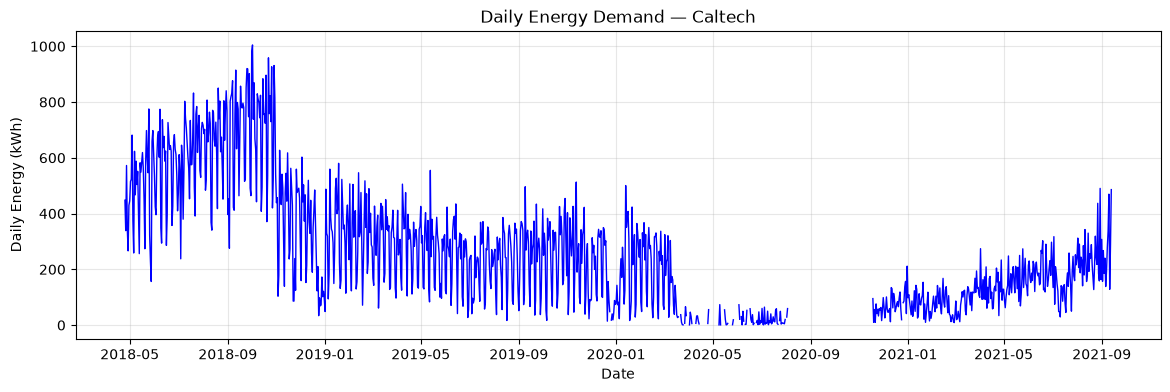

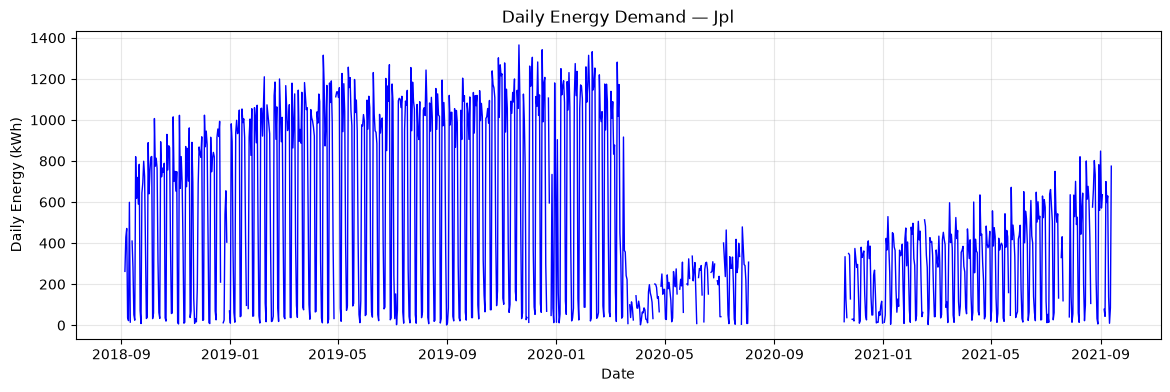

In [13]:
import matplotlib.pyplot as plt

# Create a separate graph for each charging site.
for site in daily_complete_df["site"].unique():

    # Select the data for the current site.
    site_data = daily_complete_df[
        daily_complete_df["site"] == site
    ]

    # Create the graph.
    plt.figure(figsize=(14, 4))

    plt.plot(
        site_data["date"],
        site_data["dailyEnergy"],
        color="blue",
        linewidth=1
    )

    # Add the graph labels.
    plt.title(f"Daily Energy Demand — {site.title()}")
    plt.xlabel("Date")
    plt.ylabel("Daily Energy (kWh)")
    plt.grid(alpha=0.3)

    plt.show()

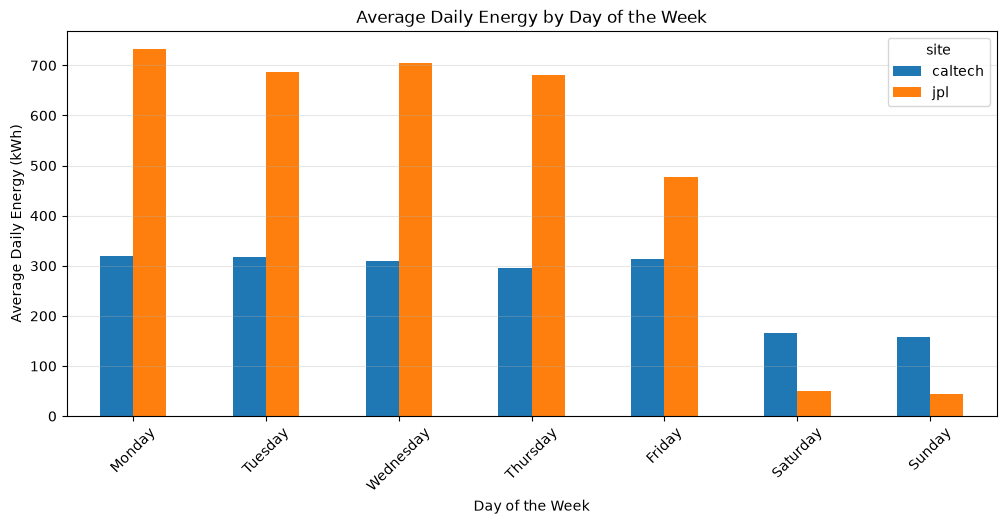

In [14]:
# Get the weekday name from each date.
eda_df["dayOfWeek"] = eda_df["date"].dt.day_name()

# Arrange the weekdays in their correct order.
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

# Calculate the average daily energy for every weekday and site.
weekday_energy = (
    eda_df.groupby(
        ["site", "dayOfWeek"],
        as_index=False
    )["dailyEnergy"]
    .mean()
)

# Arrange the results for plotting.
weekday_table = (
    weekday_energy
    .pivot(
        index="dayOfWeek",
        columns="site",
        values="dailyEnergy"
    )
    .reindex(weekday_order)
)

# Create the bar graph.
weekday_table.plot(
    kind="bar",
    figsize=(12, 5)
)

plt.title("Average Daily Energy by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Daily Energy (kWh)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [15]:
# Arrange the data chronologically.
daily_complete_df = daily_complete_df.sort_values(
    ["site", "date"]
).reset_index(drop=True)

# Use the energy from seven days earlier as the prediction.
daily_complete_df["seasonalNaivePrediction"] = (
    daily_complete_df.groupby("site")["dailyEnergy"]
    .shift(7)
)

# Display the result.
daily_complete_df[
    [
        "site",
        "date",
        "dailyEnergy",
        "seasonalNaivePrediction"
    ]
].head(15)

,site,date,dailyEnergy,seasonalNaivePrediction
0,caltech,2018-04-25,447.938000,NaN
1,caltech,2018-04-26,338.813000,NaN
2,caltech,2018-04-27,572.427000,NaN
3,caltech,2018-04-28,341.136000,NaN
4,caltech,2018-04-29,266.255000,NaN
5,caltech,2018-04-30,429.671332,NaN
6,caltech,2018-05-01,445.684000,NaN
7,caltech,2018-05-02,515.427000,447.938000
8,caltech,2018-05-03,522.652000,338.813000
9,caltech,2018-05-04,681.456019,572.427000


In [16]:
# Create energy values from previous days.
for lag in [1, 7, 14, 28]:
    daily_complete_df[f"energyLag{lag}"] = (
        daily_complete_df.groupby("site")["dailyEnergy"]
        .shift(lag)
    )

# Create calendar features.
daily_complete_df["dayOfWeek"] = (
    daily_complete_df["date"].dt.dayofweek
)

daily_complete_df["month"] = (
    daily_complete_df["date"].dt.month
)

daily_complete_df["isWeekend"] = (
    daily_complete_df["dayOfWeek"] >= 5
).astype(int)

# Store the features that will be used by the models.
feature_columns = [
    "energyLag1",
    "energyLag7",
    "energyLag14",
    "energyLag28",
    "dayOfWeek",
    "month",
    "isWeekend"
]

daily_complete_df[
    ["site", "date", "dailyEnergy", *feature_columns]
].head(15)

,site,date,dailyEnergy,energyLag1,energyLag7,energyLag14,energyLag28,dayOfWeek,month,isWeekend
0,caltech,2018-04-25,447.938000,NaN,NaN,NaN,NaN,2,4,0
1,caltech,2018-04-26,338.813000,447.938000,NaN,NaN,NaN,3,4,0
2,caltech,2018-04-27,572.427000,338.813000,NaN,NaN,NaN,4,4,0
3,caltech,2018-04-28,341.136000,572.427000,NaN,NaN,NaN,5,4,1
4,caltech,2018-04-29,266.255000,341.136000,NaN,NaN,NaN,6,4,1
5,caltech,2018-04-30,429.671332,266.255000,NaN,NaN,NaN,0,4,0
6,caltech,2018-05-01,445.684000,429.671332,NaN,NaN,NaN,1,5,0
7,caltech,2018-05-02,515.427000,445.684000,447.938000,NaN,NaN,2,5,0
8,caltech,2018-05-03,522.652000,515.427000,338.813000,NaN,NaN,3,5,0
9,caltech,2018-05-04,681.456019,522.652000,572.427000,NaN,NaN,4,5,0


In [17]:
# Keep rows with complete target, prediction, and feature values.
model_df = daily_complete_df.dropna(
    subset=[
        "dailyEnergy",
        "seasonalNaivePrediction",
        *feature_columns
    ]
).copy()

# Check the usable data for each site.
model_df.groupby("site").agg(
    startDate=("date", "min"),
    endDate=("date", "max"),
    usableDays=("date", "size")
)

,startDate,endDate,usableDays
site,,,
caltech,2018-05-23,2021-09-13,959
jpl,2018-10-03,2021-09-13,806


In [18]:
# Arrange the usable records chronologically.
model_df = model_df.sort_values(
    ["site", "date"]
).reset_index(drop=True)

# Create the dataset split column.
model_df["dataSplit"] = ""

# Split each site separately.
for site in model_df["site"].unique():

    site_indices = model_df.index[
        model_df["site"] == site
    ]

    train_end = int(len(site_indices) * 0.60)
    validation_end = int(len(site_indices) * 0.80)

    model_df.loc[
        site_indices[:train_end],
        "dataSplit"
    ] = "train"

    model_df.loc[
        site_indices[train_end:validation_end],
        "dataSplit"
    ] = "validation"

    model_df.loc[
        site_indices[validation_end:],
        "dataSplit"
    ] = "test"

# Check the date range and size of each split.
model_df.groupby(
    ["site", "dataSplit"]
).agg(
    startDate=("date", "min"),
    endDate=("date", "max"),
    totalDays=("date", "size")
)

startDate    endDate  totalDays
site    dataSplit                                  
caltech test       2021-03-06 2021-09-13        192
        train      2018-05-23 2019-12-18        575
        validation 2019-12-19 2021-03-05        192
jpl     test       2021-02-23 2021-09-13        162
        train      2018-10-03 2020-03-06        483
        validation 2020-03-07 2021-02-21        161

In [19]:
import numpy as np

# Create a list for the results.
results = []

# Evaluate each site separately.
for site in model_df["site"].unique():

    for split in ["validation", "test"]:

        evaluation_data = model_df[
            (model_df["site"] == site)
            & (model_df["dataSplit"] == split)
        ]

        actual = evaluation_data["dailyEnergy"]
        predicted = evaluation_data["seasonalNaivePrediction"]

        mae = np.mean(np.abs(actual - predicted))

        rmse = np.sqrt(
            np.mean((actual - predicted) ** 2)
        )

        results.append({
            "site": site,
            "dataSplit": split,
            "evaluatedDays": len(evaluation_data),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2)
        })

# Display the results.
seasonal_naive_results = pd.DataFrame(results)

seasonal_naive_results

,site,dataSplit,evaluatedDays,MAE,RMSE
0,caltech,validation,192,58.24,86.69
1,caltech,test,192,66.06,88.02
2,jpl,validation,161,95.80,154.96
3,jpl,test,162,126.44,196.97


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Store the models and validation results.
rf_models = {}
rf_validation_results = []

# Train one model for each site.
for site in model_df["site"].unique():

    train_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "train")
    ]

    validation_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "validation")
    ]

    X_train = train_data[feature_columns]
    y_train = train_data["dailyEnergy"]

    X_validation = validation_data[feature_columns]
    y_validation = validation_data["dailyEnergy"]

    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)

    mae = np.mean(
        np.abs(y_validation - predictions)
    )

    rmse = np.sqrt(
        np.mean((y_validation - predictions) ** 2)
    )

    rf_models[site] = model

    rf_validation_results.append({
        "site": site,
        "evaluatedDays": len(validation_data),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })

pd.DataFrame(rf_validation_results)

,site,evaluatedDays,MAE,RMSE
0,caltech,192,117.31,133.6
1,jpl,161,152.20,269.7


In [21]:
# Settings to test.
depth_options = [5, 10, 15, None]
leaf_options = [1, 3, 5, 10]

# Store the best settings and results.
best_rf_params = {}
best_rf_models = {}
best_rf_results = []

for site in model_df["site"].unique():

    train_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "train")
    ]

    validation_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "validation")
    ]

    X_train = train_data[feature_columns]
    y_train = train_data["dailyEnergy"]

    X_validation = validation_data[feature_columns]
    y_validation = validation_data["dailyEnergy"]

    best_rmse = float("inf")

    # Try every depth and leaf combination.
    for depth in depth_options:
        for leaf in leaf_options:

            model = RandomForestRegressor(
                n_estimators=200,
                max_depth=depth,
                min_samples_leaf=leaf,
                random_state=42
            )

            model.fit(X_train, y_train)

            predictions = model.predict(X_validation)

            mae = np.mean(
                np.abs(y_validation - predictions)
            )

            rmse = np.sqrt(
                np.mean((y_validation - predictions) ** 2)
            )

            # Keep the settings with the lowest RMSE.
            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model
                best_depth = depth
                best_leaf = leaf
                best_mae = mae

    best_rf_models[site] = best_model

    best_rf_params[site] = {
        "max_depth": best_depth,
        "min_samples_leaf": best_leaf
    }

    best_rf_results.append({
        "site": site,
        "maxDepth": best_depth,
        "minSamplesLeaf": best_leaf,
        "MAE": round(best_mae, 2),
        "RMSE": round(best_rmse, 2)
    })

pd.DataFrame(best_rf_results)

,site,maxDepth,minSamplesLeaf,MAE,RMSE
0,caltech,5,10,98.86,117.03
1,jpl,10,1,151.94,268.66


In [23]:
from xgboost import XGBRegressor

# Store the models and validation results.
xgb_models = {}
xgb_validation_results = []

# Train one model for each site.
for site in model_df["site"].unique():

    train_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "train")
    ]

    validation_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "validation")
    ]

    X_train = train_data[feature_columns]
    y_train = train_data["dailyEnergy"]

    X_validation = validation_data[feature_columns]
    y_validation = validation_data["dailyEnergy"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    predictions = model.predict(X_validation)

    mae = np.mean(
        np.abs(y_validation - predictions)
    )

    rmse = np.sqrt(
        np.mean((y_validation - predictions) ** 2)
    )

    xgb_models[site] = model

    xgb_validation_results.append({
        "site": site,
        "evaluatedDays": len(validation_data),
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2)
    })

pd.DataFrame(xgb_validation_results)

,site,evaluatedDays,MAE,RMSE
0,caltech,192,99.37,123.65
1,jpl,161,177.05,278.53


In [25]:
# Settings to test.
depth_options = [2, 3, 5]
learning_rate_options = [0.03, 0.05, 0.1]
sampling_options = [0.8, 1.0]

best_xgb_params = {}
best_xgb_models = {}
best_xgb_results = []

for site in model_df["site"].unique():

    train_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "train")
    ]

    validation_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "validation")
    ]

    X_train = train_data[feature_columns]
    y_train = train_data["dailyEnergy"]

    X_validation = validation_data[feature_columns]
    y_validation = validation_data["dailyEnergy"]

    best_rmse = float("inf")

    for depth in depth_options:
        for rate in learning_rate_options:
            for sampling in sampling_options:

                model = XGBRegressor(
                    n_estimators=200,
                    max_depth=depth,
                    learning_rate=rate,
                    subsample=sampling,
                    colsample_bytree=sampling,
                    objective="reg:squarederror",
                    random_state=42
                )

                model.fit(X_train, y_train)

                predictions = model.predict(X_validation)

                mae = np.mean(
                    np.abs(y_validation - predictions)
                )

                rmse = np.sqrt(
                    np.mean((y_validation - predictions) ** 2)
                )

                if rmse < best_rmse:
                    best_rmse = rmse
                    best_model = model
                    best_depth = depth
                    best_rate = rate
                    best_sampling = sampling
                    best_mae = mae

    best_xgb_models[site] = best_model

    best_xgb_params[site] = {
        "max_depth": best_depth,
        "learning_rate": best_rate,
        "sampling": best_sampling
    }

    best_xgb_results.append({
        "site": site,
        "maxDepth": best_depth,
        "learningRate": best_rate,
        "sampling": best_sampling,
        "MAE": round(best_mae, 2),
        "RMSE": round(best_rmse, 2)
    })

pd.DataFrame(best_xgb_results)

,site,maxDepth,learningRate,sampling,MAE,RMSE
0,caltech,2,0.03,0.8,82.41,99.09
1,jpl,3,0.10,1.0,170.27,275.56


In [26]:
# Store the final models, predictions, and results.
final_rf_models = {}
final_xgb_models = {}
prediction_tables = []
final_results = []

for site in model_df["site"].unique():

    # Combine training and validation data.
    training_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"].isin(["train", "validation"]))
    ]

    # Select the final test data.
    test_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"] == "test")
    ]

    X_train = training_data[feature_columns]
    y_train = training_data["dailyEnergy"]

    X_test = test_data[feature_columns]
    actual = test_data["dailyEnergy"].to_numpy()

    # Retrain Random Forest using its best settings.
    rf_settings = best_rf_params[site]

    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=rf_settings["max_depth"],
        min_samples_leaf=rf_settings["min_samples_leaf"],
        random_state=42
    )

    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    # Retrain XGBoost using its best settings.
    xgb_settings = best_xgb_params[site]

    xgb_model = XGBRegressor(
        n_estimators=200,
        max_depth=xgb_settings["max_depth"],
        learning_rate=xgb_settings["learning_rate"],
        subsample=xgb_settings["sampling"],
        colsample_bytree=xgb_settings["sampling"],
        objective="reg:squarederror",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Get the Seasonal Naive predictions.
    seasonal_predictions = test_data[
        "seasonalNaivePrediction"
    ].to_numpy()

    # Save the final models.
    final_rf_models[site] = rf_model
    final_xgb_models[site] = xgb_model

    # Save the predictions for later graphs.
    site_predictions = test_data[
        ["site", "date", "dailyEnergy"]
    ].copy()

    site_predictions["seasonalNaivePrediction"] = (
        seasonal_predictions
    )

    site_predictions["randomForestPrediction"] = (
        rf_predictions
    )

    site_predictions["xgboostPrediction"] = (
        xgb_predictions
    )

    prediction_tables.append(site_predictions)

    # Calculate the final test results.
    for model_name, predicted in [
        ("Seasonal Naive", seasonal_predictions),
        ("Random Forest", rf_predictions),
        ("XGBoost", xgb_predictions)
    ]:

        mae = np.mean(np.abs(actual - predicted))

        rmse = np.sqrt(
            np.mean((actual - predicted) ** 2)
        )

        final_results.append({
            "site": site,
            "model": model_name,
            "evaluatedDays": len(test_data),
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2)
        })

# Combine all test predictions.
final_test_predictions = pd.concat(
    prediction_tables,
    ignore_index=True
)

# Display the final test results.
final_test_results = pd.DataFrame(
    final_results
).sort_values(
    ["site", "RMSE"]
).reset_index(drop=True)

final_test_results

,site,model,evaluatedDays,MAE,RMSE
0,caltech,XGBoost,192,59.77,76.77
1,caltech,Random Forest,192,60.80,78.08
2,caltech,Seasonal Naive,192,66.06,88.02
3,jpl,XGBoost,162,106.82,158.83
4,jpl,Random Forest,162,107.87,164.98
5,jpl,Seasonal Naive,162,126.44,196.97


**ADWIN detected no significant drift in the final 20% test period**

In [28]:
from river import drift

# Store detected changes.
adwin_detections = []

# Check each site separately.
for site in final_test_predictions["site"].unique():

    site_data = final_test_predictions[
        final_test_predictions["site"] == site
    ].sort_values("date")

    # Create an ADWIN detector.
    detector = drift.ADWIN(
        delta=0.002,
        clock=1
    )

    # Process the test days chronologically.
    for _, row in site_data.iterrows():

        absolute_error = abs(
            row["dailyEnergy"]
            - row["xgboostPrediction"]
        )

        detector.update(float(absolute_error))

        if detector.drift_detected:
            adwin_detections.append({
                "site": site,
                "driftDate": row["date"],
                "absoluteError": round(absolute_error, 2),
                "windowSize": detector.width
            })

# Display the detected changes.
adwin_results = pd.DataFrame(
    adwin_detections,
    columns=[
        "site",
        "driftDate",
        "absoluteError",
        "windowSize"
    ]
)

adwin_results

,site,driftDate,absoluteError,windowSize


**Let ADWIN monitor 40% instead of 20% of the dataset**

In [29]:
# Store the longer error stream and detected changes.
adwin_stream_records = []
adwin_detections_40 = []

for site in model_df["site"].unique():

    # Use the XGBoost model trained on the training set.
    model = best_xgb_models[site]

    # Monitor the validation and test periods.
    monitoring_data = model_df[
        (model_df["site"] == site)
        & (model_df["dataSplit"].isin(["validation", "test"]))
    ].sort_values("date")

    detector = drift.ADWIN(
        delta=0.002,
        clock=1
    )

    # Process one day at a time.
    for index in monitoring_data.index:

        X_day = monitoring_data.loc[
            [index],
            feature_columns
        ]

        actual = monitoring_data.loc[
            index,
            "dailyEnergy"
        ]

        prediction = model.predict(X_day)[0]

        absolute_error = abs(
            actual - prediction
        )

        detector.update(float(absolute_error))

        detected = detector.drift_detected

        adwin_stream_records.append({
            "site": site,
            "date": monitoring_data.loc[index, "date"],
            "dataSplit": monitoring_data.loc[index, "dataSplit"],
            "actualEnergy": actual,
            "prediction": prediction,
            "absoluteError": absolute_error,
            "driftDetected": detected
        })

        if detected:
            adwin_detections_40.append({
                "site": site,
                "driftDate": monitoring_data.loc[index, "date"],
                "dataSplit": monitoring_data.loc[index, "dataSplit"],
                "absoluteError": round(absolute_error, 2),
                "windowSize": detector.width
            })

# Convert the results into tables.
adwin_stream_df = pd.DataFrame(adwin_stream_records)

adwin_40_results = pd.DataFrame(
    adwin_detections_40,
    columns=[
        "site",
        "driftDate",
        "dataSplit",
        "absoluteError",
        "windowSize"
    ]
)

adwin_40_results

,site,driftDate,dataSplit,absoluteError,windowSize
0,caltech,2021-05-09,test,32.88,225.0
1,jpl,2020-06-09,validation,78.80,42.0
2,jpl,2021-09-06,test,905.02,219.0
